In [2]:
# --- 5. Execution ---

res = []
Ns = 10:100:1000
for N_atoms in Ns
    println(N_atoms)
    flush(stdout)
    Imax = []
        for xi in range(0.0, 2.3, 50)
            Gamma = 1.0
            N_trajectories = 500
            t_max = 1.0

            t_axis, I_avg = simulate_ensemble(N_atoms, Gamma, N_atoms * xi, N_trajectories, t_max)
            push!(Imax, maximum(I_avg) / N_atoms ^ 2)
            #plot(t_axis, I_avg / N_atoms ^ 2)
        end
    push!(res, Imax)
end

10
110
210
310
410
510
610
710
810
910


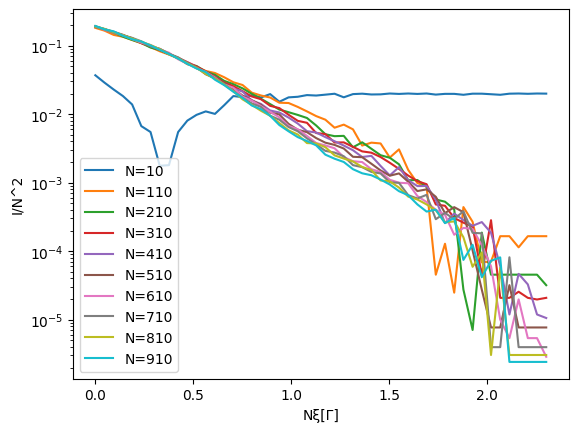

In [3]:
for (i,N_atoms) in enumerate(Ns)
    plot(range(0.0, 2.3, 50), abs.(res[i] .- 2 / N_atoms), label = "N=$N_atoms")
end
ylabel("I/N^2")
xlabel("Nξ[Γ]")
yscale(:log)
legend()
savefig("scaling.pdf", bbox_inches = "tight")


In [4]:
using LsqFit

function create_model_function(N_fixed)
    # This inner function is the one LsqFit will call
    function model_intensity(x, p)
        k = p[1] # The only free parameter is the decay constant k
        N_atoms = N_fixed # N_atoms is fixed for this fit

        # The model function from your request, divided by N_atoms^2 for normalization
        # I(t) / N^2 = [ (N^2/5 - 2N) * exp(-k * x) + 2N ] / N^2
        return (N_atoms^2/5 .* exp.(-k .* x) .+ 2*N_atoms * (1 .- exp.(-k .* x)))
    end
    return model_intensity
end

create_model_function (generic function with 1 method)

In [5]:
res = []
Ns = 40:25:2000
for N_atoms in Ns
    println(N_atoms)
    Imax = []
        for xi in range(0.0, 2.5, 50)
            Gamma = 1.0
            N_trajectories = 1000
            t_max = 1.0

            t_axis, I_avg = simulate_ensemble(N_atoms, Gamma, N_atoms * xi, N_trajectories, t_max)
            push!(Imax, maximum(I_avg))
            #plot(t_axis, I_avg / N_atoms ^ 2)
        end
    push!(res, Imax)
end

chis = range(0.0, 2.0, 50)
cmap = plt.get_cmap("viridis")

# Generate a list of colors by sampling the colormap evenly from 0.0 to 1.0
# The 'cmap' object is callable with a float between 0 and 1.
color_indices = range(0, 1, length=length(Ns))
colors = [cmap(c) for c in color_indices]


40
65
90
115
140
165
190
215
240
265
290
315
340
365
390
415
440
465
490
515
540
565
590
615
640
665
690
715
740
765
790
815
840
865
890
915
940
965
990
1015
1040
1065
1090
1115
1140
1165
1190
1215
1240
1265
1290
1315
1340
1365
1390
1415
1440
1465
1490
1515
1540
1565
1590
1615
1640
1665
1690
1715
1740
1765
1790
1815
1840
1865
1890
1915
1940
1965
1990


79-element Vector{NTuple{4, Float64}}:
 (0.267004, 0.004874, 0.329415, 1.0)
 (0.271305, 0.019942, 0.347269, 1.0)
 (0.274952, 0.037752, 0.364543, 1.0)
 (0.277941, 0.056324, 0.381191, 1.0)
 (0.280894, 0.078907, 0.402329, 1.0)
 (0.282327, 0.094955, 0.417331, 1.0)
 (0.283091, 0.110553, 0.431554, 1.0)
 (0.283187, 0.125848, 0.44496, 1.0)
 (0.28229, 0.145912, 0.46151, 1.0)
 (0.280868, 0.160771, 0.472899, 1.0)
 (0.278826, 0.17549, 0.483397, 1.0)
 (0.275191, 0.194905, 0.496005, 1.0)
 (0.271828, 0.209303, 0.504434, 1.0)
 ⋮
 (0.626579, 0.854645, 0.223353, 1.0)
 (0.668054, 0.861999, 0.196293, 1.0)
 (0.699415, 0.867117, 0.175971, 1.0)
 (0.730889, 0.871916, 0.156029, 1.0)
 (0.772852, 0.877868, 0.131109, 1.0)
 (0.804182, 0.882046, 0.114965, 1.0)
 (0.83527, 0.886029, 0.102646, 1.0)
 (0.866013, 0.889868, 0.095953, 1.0)
 (0.906311, 0.894855, 0.098125, 1.0)
 (0.935904, 0.89857, 0.108131, 1.0)
 (0.964894, 0.902323, 0.123941, 1.0)
 (0.993248, 0.906157, 0.143936, 1.0)

In [6]:
using PyPlot
using PyCall

function latex_plot_setup(; linewidth_pt=345.0,   # LaTeX \linewidth in pt
    fraction=0.5,           # Fraction of \linewidth for figure width
    font_size_pt=10,         # Font size in pt
    scale=1.0,
    ratio = (sqrt(5) - 1) / 2)               # Scale factor for notebook display
# Convert pt to inches
width_in = linewidth_pt * fraction / 72.27
width_in *= scale
height_in = width_in * ratio # Golden ratio
recommended_linewidth = 0.12 * font_size_pt * scale

# Set matplotlib settings
PyPlot.matplotlib.rc("text.latex", preamble="\\usepackage{physics,bm}")
PyPlot.matplotlib.rc("text", usetex=true)
PyPlot.matplotlib.rc("font", family="serif", size=font_size_pt * scale)
PyPlot.matplotlib.rc("lines", linewidth=recommended_linewidth)
PyPlot.matplotlib.rc("figure", figsize=(width_in, height_in))

PyPlot.matplotlib.rc("xtick.major", size=4)  # length of major ticks
PyPlot.matplotlib.rc("ytick.major", size=4)
PyPlot.matplotlib.rc("xtick.major", pad=4)   # padding between tick and label
PyPlot.matplotlib.rc("ytick.major", pad=4)

axis_linewidth = 0.1 * font_size_pt * scale

PyPlot.matplotlib.rc("axes", linewidth=axis_linewidth)
#PyPlot.matplotlib.rc("xtick", width=axis_linewidth)
#PyPlot.matplotlib.rc("ytick", width=axis_linewidth)
legend_fontsize = 1.0 * font_size_pt * scale
legend_marker_scale = 0.05  # scale down legend line/marker size

PyPlot.matplotlib.rc("legend", fontsize=legend_fontsize)
PyPlot.matplotlib.rc("legend", handlelength=2.0) 

cycler = pyimport("matplotlib").cycler
# Combine color and linestyle cycles
colors = ["black", "blue", "orange", "green"] # default colors
linestyles = ["-", "-.", "--", ":"]

# Repeat to match lengths
n = length(colors)
full_cycle = cycler("color", repeat(colors, inner=n ÷ length(colors))) +
              cycler("linestyle", repeat(linestyles, inner=n ÷ length(linestyles)))
PyPlot.matplotlib.rc("axes", prop_cycle=full_cycle)


return (width_in, height_in)
end

macro R_str(s)
    s
end

@R_str (macro with 1 method)

In [7]:
fits = []
latex_plot_setup(scale = 3.0)

for (i,N_atoms) in enumerate(Ns)
    #axhline(2 / N_atoms, color = colors[i])
    model = (N_atoms^2/5-2*N_atoms) * exp.(-3* chis) .+ 2*N_atoms * (1 .- exp.(-3* chis))

    fit = curve_fit(create_model_function(N_atoms), collect(chis), res[i], [3.0])
    push!(fits, fit.param[1])

    if i == 66
        println(N_atoms)
        plot(chis, res[i] / N_atoms ^ 2, color = colors[i])
        plot(chis, model / N_atoms ^ 2, color = colors[i], linestyle = "dotted")
    end
end
axhline(1/ 5)

figure()
latex_plot_setup()
scatter(Ns, fits, facecolor = "none", edgecolor = "k", s = 4)
xlabel("N")
ylabel("G(N)")
savefig("data/G_data.pdf", bbox_inches = "tight")

1665


LoadError: PyError ($(Expr(:escape, :(ccall(#= /Users/nicobassler/.julia/packages/PyCall/1gn3u/src/pyfncall.jl:43 =# @pysym(:PyObject_Call), PyPtr, (PyPtr, PyPtr, PyPtr), o, pyargsptr, kw))))) <class 'FileNotFoundError'>
FileNotFoundError(2, 'No such file or directory')
  File "/Users/nicobassler/.pyenv/versions/julia/lib/python3.14/site-packages/matplotlib/pyplot.py", line 1250, in savefig
    res = fig.savefig(*args, **kwargs)  # type: ignore[func-returns-value]
  File "/Users/nicobassler/.pyenv/versions/julia/lib/python3.14/site-packages/matplotlib/figure.py", line 3490, in savefig
    self.canvas.print_figure(fname, **kwargs)
    ~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/Users/nicobassler/.pyenv/versions/julia/lib/python3.14/site-packages/matplotlib/backend_bases.py", line 2186, in print_figure
    result = print_method(
        filename,
    ...<3 lines>...
        bbox_inches_restore=_bbox_inches_restore,
        **kwargs)
  File "/Users/nicobassler/.pyenv/versions/julia

[2.4652008538605377, 0.15018562834063565]


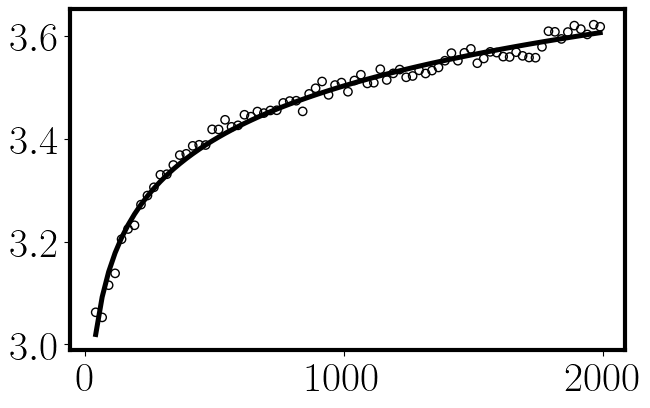

In [ ]:
latex_plot_setup(scale = 3.0)

log_model(x,p) = p[1] .+ p[2] .* log.(x)
ps = curve_fit(log_model, collect(Ns), fits, [1.0,1.0]).param
plot(Ns, log_model.(Ns, Ref(ps)))
scatter(Ns, fits, facecolor = "none", edgecolor = "k")
println(ps)

In [1]:
using SparseArrays
using QuantumOptics
using PyPlot
using SpecialFunctions

"""
    block_ranges(space::SumBasis)

Given a direct sum basis `space`, returns a vector of UnitRange{Int},
where each element gives the global index range corresponding to each subspace.
"""
function block_ranges(space::SumBasis)
    ranges = Vector{UnitRange{Int}}(undef, length(space.shape))
    start = 1
    for (i, len) in enumerate(space.shape)
        ranges[i] = start:(start+len-1)
        start += len
    end
    return ranges
end


"""
    build_operator(N, matrix_element)

Constructs a sparse operator over the Dicke Hilbert space (direct sum of SpinBasis blocks)
for a system of N atoms. The input `matrix_element` is a function with signature

    matrix_element(N, J, M, Jp, Mp) -> ComplexF64

which returns the matrix element connecting state |J, M⟩ in one block to |Jp, Mp⟩ in another.
Only nonzero values are stored.

Returns a tuple (op, space) where `op` is the operator (sparse matrix) and `space` is
the constructed SumBasis.
"""
function build_operator(N::Int, matrix_element::Function)
    # Construct the Dicke Hilbert space as a direct sum of SpinBasis blocks.
    subs = dicke_subspaces(N)         # vector of SpinBasis for each allowed J
    space = directsum(subs...)          # the full SumBasis
    total_dim = length(space)           # total dimension of the Hilbert space
    op = spzeros(ComplexF64, total_dim, total_dim)
    
    # Obtain global index ranges for each block in the direct sum.
    br = block_ranges(space)
    
    # Loop over all pairs of blocks: source block (with spin J) and target block (with spin Jp)
    for (i, b_source) in enumerate(subs)
        J = b_source.spinnumber
        dim_source = length(b_source)   # dimension = 2J + 1
        for (j, b_target) in enumerate(subs)
            Jp = b_target.spinnumber
            dim_target = length(b_target)  # dimension = 2Jp + 1
            
            # Get the global index ranges for these blocks.
            range_source = br[i]
            range_target = br[j]
            
            # Loop over basis states in the source block.
            # Convention: basis index k corresponds to M = J - (k - 1)
            for k_source in 1:dim_source
                M = J - (k_source - 1)
                # And similarly for the target block:
                for k_target in 1:dim_target
                    Mp = Jp - (k_target - 1)
                    val = matrix_element(N, J, M, Jp, Mp)
                    if val != 0
                        global_source = range_source[k_source]
                        global_target = range_target[k_target]
                        op[global_target, global_source] = val
                    end
                end
            end
        end
    end
    return SparseOperator(space, op)
end

function matrix_element_collective_decay(N, J, M, Jp, Mp)
    # Nonzero only if J remains the same and Mp = M - 1.
    if J == Jp && Mp == M - 1
        return A_JM_minus(J, M)
    else
        return 0.0
    end
end

# Collective factors (used also in the individual channels):
"""
    A_JM_minus(J, M)

Collective lowering amplitude:
  A_{JM}⁻ = √[(J + M)(J – M + 1)]
"""
A_JM_minus(J, M) = sqrt((J + M) * (J - M + 1))

"""
    A_JM_plus(J, M)

Collective raising amplitude:
  A_{JM}⁺ = √[(J – M)(J + M + 1)]
"""
A_JM_plus(J, M) = sqrt((J - M) * (J + M + 1))

# ---------------------------
# Individual Decay (lowering M)
# ---------------------------

"""
    P_JM_minus_0(J, M, N)

Individual decay channel with no change in J:
  P_{JM}^{-,0} = √[(2+N)/(4J(J+1))] A_{JM}⁻.
"""
P_JM_minus_0(J, M, N) = sqrt((2 + N) / (4 * J * (J + 1))) * A_JM_minus(J, M)

"""
    P_JM_minus_minus(J, M, N)

Individual decay channel lowering J by 1 (“s = -1”):
  P_{JM}^{-,-} = -√[(N+2J+2)(J+M)(J+M-1)/(4J(2J+1))].
"""
P_JM_minus_minus(J, M, N) = -sqrt((N + 2 * J + 2) * (J + M) * (J + M - 1) / (4 * J * (2 * J + 1)))

"""
    P_JM_minus_plus(J, M, N)

Individual decay channel increasing J by 1 (“s = +1”):
  P_{JM}^{-,+} = √[(N-2J)(J-M+1)(J-M+2)/(4(J+1)(2J+1))].
"""
P_JM_minus_plus(J, M, N) = sqrt((N - 2 * J) * (J - M + 1) * (J - M + 2) / (4 * (J + 1) * (2 * J + 1)))

# ---------------------------
# Individual Pumping (raising M)
# ---------------------------

"""
    P_JM_plus_0(J, M, N)

Individual pumping channel with no change in J:
  P_{JM}^{+,0} = √[(2+N)/(4J(J+1))] A_{JM}⁺.
"""
P_JM_plus_0(J, M, N) = sqrt((2 + N) / (4 * J * (J + 1))) * A_JM_plus(J, M)

"""
    P_JM_plus_minus(J, M, N)

Individual pumping channel lowering J by 1 (“s = -1”):
  P_{JM}^{+,-} = √[(N+2J+2)(J-M)(J-M-1)/(4J(2J+1))].
"""
P_JM_plus_minus(J, M, N) = sqrt((N + 2 * J + 2) * (J - M) * (J - M - 1) / (4 * J * (2 * J + 1)))

"""
    P_JM_plus_plus(J, M, N)

Individual pumping channel increasing J by 1 (“s = +1”):
  P_{JM}^{+,+} = -√[(N-2J)(J+M+1)(J+M+2)/(4(J+1)(2J+1))].
"""
P_JM_plus_plus(J, M, N) = -sqrt((N - 2 * J) * (J + M + 1) * (J + M + 2) / (4 * (J + 1) * (2 * J + 1)))

# ---------------------------
# Individual Dephasing
# ---------------------------

"""
    P_JM_z_0(J, M, N)

Individual dephasing channel that leaves M unchanged:
  P_{JM}^{z,0} = √[(2+N)/(4J(J+1))] M.
"""
function P_JM_z_0(J, M, N)
    if J == 0
        return 0.0
    else
        return sqrt((2 + N) / (4 * J * (J + 1))) * M
    end
end
#P_JM_z_0(J, M, N) = sqrt((2 + N) / (4 * J * (J + 1))) * M

"""
    P_JM_z_minus(J, M, N)

Individual dephasing channel lowering J by 1 (“s = -”):
  P_{JM}^{z,-} = √[(N+2J+2)(J-M)(J+M)/(4J(2J+1))].
"""
P_JM_z_minus(J, M, N) = sqrt((N + 2 * J + 2) * (J - M) * (J + M) / (4 * J * (2 * J + 1)))

"""
    P_JM_z_plus(J, M, N)

Individual dephasing channel increasing J by 1 (“s = +”):
  P_{JM}^{z,+} = √[(N-2J)(J+1-M)(J+1+M)/(4(J+1)(2J+1))].
"""
P_JM_z_plus(J, M, N) = sqrt((N - 2 * J) * (J + 1 - M) * (J + 1 + M) / (4 * (J + 1) * (2 * J + 1)))


"""
d_N_J(N, J)

Returns the degeneracy factor for a Dicke state with N atoms and total spin J,
defined by

  d_N^J = (N! (2J+1)) / ((N/2 - J)! (N/2 + J + 1)!)
      = Γ(N+1) (2J+1) / (Γ(N/2 - J + 1) Γ(N/2 + J + 2))
"""
function d_N_J(N::Int, J::Real)
    return 1.0 #gamma(N + 1) * (2 * J + 1) / (gamma(N/2 - J + 1) * gamma(N/2 + J + 2))
end

allowed_J(N) = (N % 2 == 0) ? collect(0:1:N÷2) : collect(1//2:1:N÷2)


# Create a list of SpinBasis subspaces for the allowed total spins
function dicke_subspaces(N::Int)
    js = (N % 2 == 0) ? [j for j in 0:N÷2] : [j//2 for j in 1:2:N]
    return reverse([SpinBasis(j) for j in js])
end

# Full Dicke Hilbert space as a direct sum
function dicke_space(N::Int)
    return directsum(dicke_subspaces(N)...)
end

# -- Matrix Element Functions for Jump Operators --

# 1. Collective Decay (acts within the same J, lowering M by 1)
function matrix_element_collective_decay(N, J, M, Jp, Mp)
    if J == Jp && Mp == M - 1
        # Multiply by sqrt(degeneracy) for the source block.
        return sqrt(d_N_J(N, J)) * A_JM_minus(J, M)
    else
        return 0.0
    end
end

# 2. Individual Decay, s = 0 channel (no change in J, lowering M by 1)
function matrix_element_individual_decay_s0(N, J, M, Jp, Mp)
    if J == Jp && Mp == M - 1
        return sqrt(d_N_J(N, J)) * P_JM_minus_0(J, M, N)
    else
        return 0.0
    end
end

# 3. Individual Decay, s = -1 channel (J -> J-1, lowering M by 1)
function matrix_element_individual_decay_sminus(N, J, M, Jp, Mp)
    if Jp == J - 1 && Mp == M - 1
        return sqrt(d_N_J(N, J)) * P_JM_minus_minus(J, M, N)
    else
        return 0.0
    end
end

# 4. Individual Decay, s = +1 channel (J -> J+1, lowering M by 1)
function matrix_element_individual_decay_splus(N, J, M, Jp, Mp)
    if Jp == J + 1 && Mp == M - 1
        return sqrt(d_N_J(N, J)) * P_JM_minus_plus(J, M, N)
    else
        return 0.0
    end
end


# 1. Individual Pumping Operators:

# s = 0: No change in J, M → M+1.
function matrix_element_individual_pump_s0(N, J, M, Jp, Mp)
    if J == Jp && Mp == M + 1
        return sqrt(d_N_J(N, J)) * P_JM_plus_0(J, M, N)
    else
        return 0.0
    end
end

# s = -1: J → J - 1, M → M+1.
function matrix_element_individual_pump_sminus(N, J, M, Jp, Mp)
    if Jp == J - 1 && Mp == M + 1
        return sqrt(d_N_J(N, J)) * P_JM_plus_minus(J, M, N)
    else
        return 0.0
    end
end

# s = +1: J → J + 1, M → M+1.
function matrix_element_individual_pump_splus(N, J, M, Jp, Mp)
    if Jp == J + 1 && Mp == M + 1
        return sqrt(d_N_J(N, J)) * P_JM_plus_plus(J, M, N)
    else
        return 0.0
    end
end

# 2. Individual Dephasing Operators:

# s = 0: No change in J, M unchanged.
function matrix_element_individual_dephase_s0(N, J, M, Jp, Mp)
    if J == Jp && Mp == M
        return sqrt(d_N_J(N, J)) * P_JM_z_0(J, M, N)
    else
        return 0.0
    end
end

# s = -: J → J - 1, M unchanged.
function matrix_element_individual_dephase_sminus(N, J, M, Jp, Mp)
    if Jp == J - 1 && Mp == M
        return sqrt(d_N_J(N, J)) * P_JM_z_minus(J, M, N)
    else
        return 0.0
    end
end

# s = +: J → J + 1, M unchanged.
function matrix_element_individual_dephase_splus(N, J, M, Jp, Mp)
    if Jp == J + 1 && Mp == M
        return sqrt(d_N_J(N, J)) * P_JM_z_plus(J, M, N)
    else
        return 0.0
    end
end

QuantumOptics.sigmam(hilbert_space::SumBasis) = directsum(sigmam.(hilbert_space.bases)...)
QuantumOptics.sigmap(hilbert_space::SumBasis) = directsum(sigmap.(hilbert_space.bases)...)
QuantumOptics.sigmax(hilbert_space::SumBasis) = directsum(sigmax.(hilbert_space.bases)...)
QuantumOptics.sigmay(hilbert_space::SumBasis) = directsum(sigmay.(hilbert_space.bases)...)
QuantumOptics.sigmaz(hilbert_space::SumBasis) = directsum(sigmaz.(hilbert_space.bases)...)

function build_collapse_operators(N::Int, Γ_c, γ_l, κ_l, d_l)
    # Get the common Hilbert space for N atoms.
    common_space = dicke_space(N)
    
    # Initialize empty lists for operators and rates.
    op_list::Vector = []
    rate_list::Vector = []
    
    # 1. Collective decay operator (rate: Γ_c)
    push!(op_list, build_operator(N, matrix_element_collective_decay))
    push!(rate_list, Γ_c)
    
    # 2. Individual decay operators (rate: γ_l)
    push!(op_list, build_operator(N, matrix_element_individual_decay_s0))
    push!(rate_list, γ_l)
    
    push!(op_list, build_operator(N, matrix_element_individual_decay_sminus))
    push!(rate_list, γ_l)
    
    push!(op_list, build_operator(N, matrix_element_individual_decay_splus))
    push!(rate_list, γ_l)
    
    # 3. Individual pumping operators (rate: κ_l)
    push!(op_list, build_operator(N, matrix_element_individual_pump_s0))
    push!(rate_list, κ_l)
    
    push!(op_list, build_operator(N, matrix_element_individual_pump_sminus))
    push!(rate_list, κ_l)
    
    push!(op_list, build_operator(N, matrix_element_individual_pump_splus))
    push!(rate_list, κ_l)
    
    # 4. Individual dephasing operators (rate: d_l)
    push!(op_list, build_operator(N, matrix_element_individual_dephase_s0))
    push!(rate_list, d_l)
    
    push!(op_list, build_operator(N, matrix_element_individual_dephase_sminus))
    push!(rate_list, d_l)
    
    push!(op_list, build_operator(N, matrix_element_individual_dephase_splus))
    push!(rate_list, d_l)
    
    return common_space, op_list, rate_list
end

"""
    build_tensor_collapse_operators(N, Γ_c, γ_l, κ_l, d_l)

Constructs the full tensor‑product Hilbert space for N two‑level atoms and returns:
  - the tensor Hilbert space,
  - a list of collapse operators,
  - a list of their corresponding rates.
  
These operators can then be used to simulate the master equation in the full tensor space.
"""
function build_tensor_collapse_operators(N::Int, Γ_c, γ_l, κ_l, d_l)
    # Single-atom basis for a two-level system.
    b_atom = SpinBasis(1//2)
    # Full tensor-product Hilbert space:
    b_tensor = tensor([b_atom for i=1:N]...)
    
    # Define helper functions to embed single-atom operators into the full space:
    sm(i) = embed(b_tensor, i, sigmam(b_atom))
    sp(i) = embed(b_tensor, i, sigmap(b_atom))
    sz(i) = embed(b_tensor, i, sigmaz(b_atom))
    
    # 1. Collective decay operator: S_- = sum_i σ_-^(i)
    S_minus = sum(sm.(1:N))
    
    # 2. Individual decay operators: one per atom.
    individual_decay_ops = [ sm(i) for i in 1:N ]
    
    # 3. Individual pumping operators: one per atom.
    individual_pump_ops = [ sp(i) for i in 1:N ]
    
    # 4. Individual dephasing operators: one per atom.
    # (Often one uses sigma_z for dephasing; adjust if needed.)
    individual_dephase_ops = [ sz(i) for i in 1:N ]
    
    # Build lists for all collapse operators and their rates.
    op_list = []
    rate_list = []
    
    # Append collective decay operator:
    push!(op_list, S_minus)
    push!(rate_list, Γ_c)
    
    # Append individual decay operators:
    for op in individual_decay_ops
        push!(op_list, op)
        push!(rate_list, γ_l)
    end
    
    # Append individual pumping operators:
    for op in individual_pump_ops
        push!(op_list, op)
        push!(rate_list, κ_l)
    end
    
    # Append individual dephasing operators:
    for op in individual_dephase_ops
        push!(op_list, op)
        push!(rate_list, d_l)
    end
    
    return b_tensor, op_list, rate_list
end

function fully_excited_state_sum(N::Int)
    subs = dicke_subspaces(N)
    sum_space = directsum(subs...)
    psi_max = spinup(subs[1])
    psi_rest = [Ket(b, zeros(ComplexF64, length(b))) for b in subs[2:end]]
    ψ = directsum(psi_max, psi_rest...)
    return ψ
end

function fully_ground_state_sum(N::Int)
    subs = dicke_subspaces(N)
    sum_space = directsum(subs...)
    psi_max = spindown(subs[1])
    psi_rest = [Ket(b, zeros(ComplexF64, length(b))) for b in subs[2:end]]
    ψ = directsum(psi_max, psi_rest...)
    return ψ
end


fully_ground_state_sum (generic function with 1 method)

In [ ]:
N = 25
Γ_c = 1.0
γ_l = 0.0
κ_l = 0.0
d_l = 0.0

for d_l in range(0.0, 2.0, 10)

    sum_space, sum_op_list, sum_rate_list = build_collapse_operators(N, Γ_c, γ_l, κ_l, d_l)

    psi0_sum = fully_excited_state_sum(N)
    H_sum = SparseOperator(sum_space, spzeros(ComplexF64, length(sum_space), length(sum_space)))
    Sz_sum = sigmaz(sum_space)
    Sx_sum = sigmax(sum_space)
    Sy_sum = sigmay(sum_space)

    Sz_sum2 = Sz_sum * Sz_sum
    Sy_sum2 = Sy_sum * Sy_sum
    Sx_sum2 = Sx_sum * Sx_sum
    S2 = Sx_sum2 + Sy_sum2 + Sz_sum2

    expval_squeezing(state) = (expect(S2, state) - expect(Sx_sum, state) ^ 2 - expect(Sy_sum, state) ^ 2 - expect(Sz_sum, state) ^ 2) / (N / 2)

    tspan = range(0.0, 20.0, 100)
    t_sum, ρsum = timeevolution.master(tspan, psi0_sum, H_sum, sum_op_list; rates = sum_rate_list)

    plot(t_sum, expval_squeezing.(ρsum), label = κ_l)
end

legend()
yscale(:log)
axhline(1.0, color = "black")

/Users/nicobassler/.pyenv/versions/julia/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/nicobassler/.pyenv/versions/julia/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


LoadError: InterruptException:

In [4]:
using DataStructures
using OrdinaryDiffEq
using SparseArrays

# Collective factors (used also in the individual channels):
"""
    A_JM_minus(J, M)

Collective lowering amplitude:
  A_{JM}⁻ = √[(J + M)(J – M + 1)]
"""
A_JM_minus(J, M) = sqrt((J + M) * (J - M + 1))

"""
    A_JM_plus(J, M)

Collective raising amplitude:
  A_{JM}⁺ = √[(J – M)(J + M + 1)]
"""
A_JM_plus(J, M) = sqrt((J - M) * (J + M + 1))

# ---------------------------
# Individual Decay (lowering M)
# ---------------------------

"""
    P_JM_minus_0(J, M, N)

Individual decay channel with no change in J:
  P_{JM}^{-,0} = √[(2+N)/(4J(J+1))] A_{JM}⁻.
"""
function P_JM_minus_0(J, M, N)
    if J == 0
        return 0.0
    end
    return sqrt((2 + N) / (4 * J * (J + 1))) * A_JM_minus(J, M)
end

"""
    P_JM_minus_minus(J, M, N)

Individual decay channel lowering J by 1 (“s = -1”):
  P_{JM}^{-,-} = -√[(N+2J+2)(J+M)(J+M-1)/(4J(2J+1))].
"""
function P_JM_minus_minus(J, M, N) 
    if J == 0
        return 0.0
    end
    return -sqrt((N + 2 * J + 2) * (J + M) * (J + M - 1) / (4 * J * (2 * J + 1)))
end

"""
    P_JM_minus_plus(J, M, N)

Individual decay channel increasing J by 1 (“s = +1”):
  P_{JM}^{-,+} = √[(N-2J)(J-M+1)(J-M+2)/(4(J+1)(2J+1))].
"""
P_JM_minus_plus(J, M, N) = sqrt((N - 2 * J) * (J - M + 1) * (J - M + 2) / (4 * (J + 1) * (2 * J + 1)))

# ---------------------------
# Individual Pumping (raising M)
# ---------------------------

"""
    P_JM_plus_0(J, M, N)

Individual pumping channel with no change in J:
  P_{JM}^{+,0} = √[(2+N)/(4J(J+1))] A_{JM}⁺.
"""
function P_JM_plus_0(J, M, N)
    if J == 0
        return 0.0
    end
    return sqrt((2 + N) / (4 * J * (J + 1))) * A_JM_plus(J, M)
end

"""
    P_JM_plus_minus(J, M, N)

Individual pumping channel lowering J by 1 (“s = -1”):
  P_{JM}^{+,-} = √[(N+2J+2)(J-M)(J-M-1)/(4J(2J+1))].
"""
function P_JM_plus_minus(J, M, N)
    if J == 0
        return 0.0
    end
    return sqrt((N + 2 * J + 2) * (J - M) * (J - M - 1) / (4 * J * (2 * J + 1)))
end

"""
    P_JM_plus_plus(J, M, N)

Individual pumping channel increasing J by 1 (“s = +1”):
  P_{JM}^{+,+} = -√[(N-2J)(J+M+1)(J+M+2)/(4(J+1)(2J+1))].
"""
P_JM_plus_plus(J, M, N) = -sqrt((N - 2 * J) * (J + M + 1) * (J + M + 2) / (4 * (J + 1) * (2 * J + 1)))

# ---------------------------
# Individual Dephasing
# ---------------------------

"""
    P_JM_z_0(J, M, N)

Individual dephasing channel that leaves M unchanged:
  P_{JM}^{z,0} = √[(2+N)/(4J(J+1))] M.
"""
function P_JM_z_0(J, M, N)
    if J == 0
        return 0.0
    else
        return sqrt((2 + N) / (4 * J * (J + 1))) * M
    end
end
#P_JM_z_0(J, M, N) = sqrt((2 + N) / (4 * J * (J + 1))) * M

"""
    P_JM_z_minus(J, M, N)

Individual dephasing channel lowering J by 1 (“s = -”):
  P_{JM}^{z,-} = √[(N+2J+2)(J-M)(J+M)/(4J(2J+1))].
"""
function P_JM_z_minus(J, M, N)
    if J == 0
        return 0.0
    end
    sqrt((N + 2 * J + 2) * (J - M) * (J + M) / (4 * J * (2 * J + 1)))
end

"""
    P_JM_z_plus(J, M, N)

Individual dephasing channel increasing J by 1 (“s = +”):
  P_{JM}^{z,+} = √[(N-2J)(J+1-M)(J+1+M)/(4(J+1)(2J+1))].
"""
P_JM_z_plus(J, M, N) = sqrt((N - 2 * J) * (J + 1 - M) * (J + 1 + M) / (4 * (J + 1) * (2 * J + 1)))

function build_basis(J)
    S0 = iseven(2*J) ? 0 : 1/2
    return [(S,M) for S=S0:J for M=-S:S]
end

function sane(J,M,Jmax)
    if J > Jmax return false end
    if abs(M) > J return false end
    if J < 0 return false end
    return true
end 

"""
state is a tuple (S,M)
params is a dictionary (global_decay, global_pump, local_pump, local_decay, local_dephasing)
gives the outgoing rates and the states they point to
"""
function outgoing_for_state(state, params, Jmax)
    J, M = state
    out = DefaultDict{Tuple{Rational, Rational}, Float64}(0.0)
    # global_decay M -> M-1 and J->J
    if sane(J,M-1,Jmax) out[(J, M-1)] += A_JM_minus(J,M) * sqrt(params["global_decay"]) end
    # global_decay M -> M+1 and J->J
    if sane(J, M+1,Jmax) out[(J, M+1)] += A_JM_plus(J,M) * sqrt(params["global_pump"]) end
    # local_decay M -> M-1 and J->(J+1,J,J-1)
    if sane(J+1, M-1,Jmax) out[(J+1, M-1)] += P_JM_minus_plus(J,M,2*J) * sqrt(params["local_decay"]) end
    if sane(J-1,M-1,Jmax) out[(J-1,M-1)] += P_JM_minus_minus(J,M,2*Jmax) * sqrt(params["local_decay"]) end
    if sane(J,M-1,Jmax) out[(J,M-1)] += P_JM_minus_0(J,M,2*Jmax) * sqrt(params["local_decay"]) end
    # local_pump M -> M+1 and J->(J+1,J,J-1)
    if sane(J+1,M+1,Jmax) out[(J+1,M+1)] += P_JM_plus_plus(J,M,2*Jmax) * sqrt(params["local_pump"]) end
    if sane(J-1,M+1,Jmax) out[(J-1,M+1)] += P_JM_plus_minus(J,M,2*Jmax) * sqrt(params["local_pump"]) end
    if sane(J,M+1,Jmax) out[(J,M+1)] += P_JM_plus_0(J,M,2*Jmax) * sqrt(params["local_pump"]) end 
    # local_dephasing M -> M+1 and J->(J+1,J,J-1)
    if sane(J+1, M,Jmax) out[(J+1, M)] += P_JM_z_plus(J,M,2*Jmax) * sqrt(params["local_dephasing"]) end
    if sane(J-1, M,Jmax) out[(J-1, M)] += P_JM_z_minus(J,M,2*Jmax) * sqrt(params["local_dephasing"]) end 
    if sane(J, M,Jmax) out[(J, M)] += P_JM_z_0(J,M,2*Jmax) * sqrt(params["local_dephasing"]) end
    return out
end

function incoming_for_state(state, params, Jmax)
    J, M = state
    inp = DefaultDict{Tuple{Rational, Rational}, Float64}(0.0)

    if sane(J,M+1, Jmax); inp[(J,M+1)] += A_JM_minus(J,M+1)* sqrt(params["global_decay"]); end
    if sane(J,M-1, Jmax); inp[(J,M-1)] += A_JM_plus(J, M-1) * sqrt(params["global_pump"]); end

    if sane(J-1, M+1, Jmax); inp[(J-1,M+1)] += P_JM_minus_plus(J-1,M+1, 2*(J-1))  * sqrt(params["local_decay"]); end
    if sane(J+1, M+1, Jmax); inp[(J+1,M+1)] += P_JM_minus_minus(J+1,M+1, 2*Jmax)  * sqrt(params["local_decay"]); end
    if sane(J, M+1, Jmax); inp[(J, M+1)] += P_JM_minus_0(J,M+1, 2*Jmax)   * sqrt(params["local_decay"]); end

    if sane(J-1, M-1, Jmax); inp[(J-1, M-1)] += P_JM_plus_plus(J-1, M-1, 2*Jmax) * sqrt(params["local_pump"]); end
    if sane(J+1, M-1, Jmax); inp[(J+1, M-1)] += P_JM_plus_minus(J+1,M-1, 2*Jmax) * sqrt(params["local_pump"]); end
    if sane(J, M-1, Jmax); inp[(J, M-1)] += P_JM_plus_0(J,    M-1, 2*Jmax)* sqrt(params["local_pump"]); end

    if sane(J-1, M, Jmax); inp[(J-1, M)] += P_JM_z_plus(J-1, M, 2*Jmax) * sqrt(params["local_dephasing"]); end
    if sane(J+1, M, Jmax); inp[(J+1, M)] += P_JM_z_minus(J+1, M, 2*Jmax) * sqrt(params["local_dephasing"]); end
    if sane(J, M, Jmax); inp[(J, M)] += P_JM_z_0(J, M, 2*Jmax) * sqrt(params["local_dephasing"]); end

    return inp
end

function sum_incoming_for_state(state, params, Jmax)
    tmp = incoming_for_state(state, params, Jmax)
    return sum(x[2] ^ 2 for x in tmp)
end

function sum_outgoing_for_state(state, params, Jmax)
    tmp = outgoing_for_state(state, params, Jmax)
    return sum(x[2] ^ 2 for x in tmp)
end

function check_inversion(target, params, Jmax; atol=1e-10)
    incoming = incoming_for_state(target, params, Jmax)
    ok = true
    for (src, w_in) in incoming
        out = outgoing_for_state(src, params, Jmax)
        w_out = get(out, target, 0.0)
        ok &= isapprox(w_in, w_out; atol=atol)
        if !ok
            @warn "Mismatch" src=src target=target w_in=w_in w_out=w_out
        end
    end
    return ok
end

"""
For diagonal evolution, define the rate matrix
"""
function set_up_rate_matrix(Jmax, params)
    basis = build_basis(Jmax)
    index_mapping = Dict(basis .=> 1:length(basis))
    sparse_constructor = DefaultDict{Tuple{Int64, Int64}, Float64}(0.0)

    for state in basis
        out_rate = sum_outgoing_for_state(state, params, Jmax)
        in_rates = incoming_for_state(state, params, Jmax)
        is = index_mapping[state]
        sparse_constructor[(is, is)] -= out_rate
        for (src, rate) in in_rates
            sparse_constructor[(is, index_mapping[src])] += rate ^ 2
        end
    end


    I = Int[]; J = Int[]; V = Float64[]
    sizehint!(I, length(sparse_constructor)); sizehint!(J, length(sparse_constructor)); sizehint!(V, length(sparse_constructor))
    for ((i, j), v) in sparse_constructor
        push!(I, i); push!(J, j); push!(V, v)
    end
        
    N = length(basis)
    out = sparse(I,J,V,N,N)
    dropzeros!(out)
    return basis, index_mapping, out, N
end

function initial_state(index_mapping, state, nstates)
    u = zeros(Float64, nstates)
    u[index_mapping[state]] = 1.0
    return u
end

Jmax = 100
N = 2 * Jmax
params = Dict("global_decay" => 1.0, "global_pump" => 0.0, "local_pump" => 0.0, "local_dephasing" => 0.6 * N, "local_decay" => 0.0)

basis, index_mapping, Q, nstates = set_up_rate_matrix(Jmax, params)
p0 = initial_state(index_mapping, (Jmax, Jmax), nstates)

function f!(u, p, t)
    return Q * u
end

t = 2.0 / log(N)
prob = ODEProblem(f!, p0, (0.0, t), dt = 0.001)
sol = solve(prob, RK4())   # or Tsit5(), etc.
sum(sol.u[end])

expval_S(state, index_mapping) = sum(state[value] * key[1] for (key,value) in index_mapping)
expval_M(state, index_mapping) = sum(state[value] * key[2] for (key,value) in index_mapping)

expval_M (generic function with 1 method)

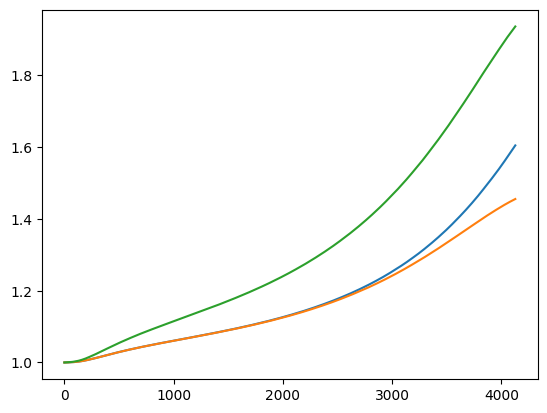

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x366d881a0>

In [ ]:
plot([expect_smk(index_mapping, basis, amp, 2, 1) / (expect_smk(index_mapping, basis, amp, 0, 1)*expect_smk(index_mapping, basis, amp, 2, 0)) for amp in sol.u])
plot([expect_smk(index_mapping, basis, amp, 1, 2) / (expect_smk(index_mapping, basis, amp, 0, 2)*expect_smk(index_mapping, basis, amp, 1, 0)) for amp in sol.u])
plot([expect_smk(index_mapping, basis, amp, 2, 2) / (expect_smk(index_mapping, basis, amp, 0, 2)*expect_smk(index_mapping, basis, amp, 2, 0)) for amp in sol.u])

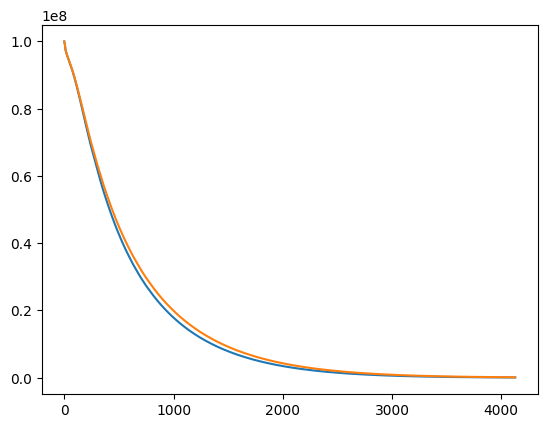

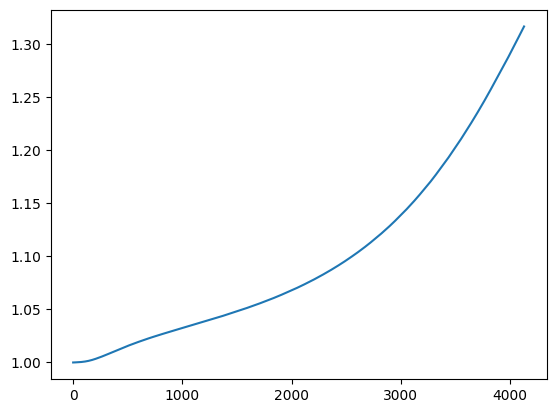

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x366c3be00>

In [ ]:
plot([expect_smk(index_mapping, basis, amp, 0, 2)*expect_smk(index_mapping, basis, amp, 2, 0) for amp in sol.u])
plot([expect_smk(index_mapping, basis, amp, 2, 2) for amp in sol.u])

figure()
plot([expect_smk(index_mapping, basis, amp, 1, 1) / (expect_smk(index_mapping, basis, amp, 0, 1)*expect_smk(index_mapping, basis, amp, 1, 0)) for amp in sol.u])

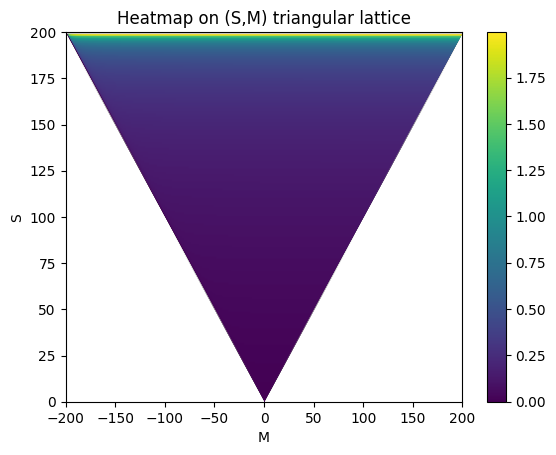

201×401 Matrix{Float64}:
 NaN  NaN    NaN        NaN         NaN        …  NaN        NaN        NaN
 NaN  NaN    NaN        NaN         NaN           NaN        NaN        NaN
 NaN  NaN    NaN        NaN         NaN           NaN        NaN        NaN
 NaN  NaN    NaN        NaN         NaN           NaN        NaN        NaN
 NaN  NaN    NaN        NaN         NaN           NaN        NaN        NaN
 NaN  NaN    NaN        NaN         NaN        …  NaN        NaN        NaN
 NaN  NaN    NaN        NaN         NaN           NaN        NaN        NaN
 NaN  NaN    NaN        NaN         NaN           NaN        NaN        NaN
 NaN  NaN    NaN        NaN         NaN           NaN        NaN        NaN
 NaN  NaN    NaN        NaN         NaN           NaN        NaN        NaN
 NaN  NaN    NaN        NaN         NaN        …  NaN        NaN        NaN
 NaN  NaN    NaN        NaN         NaN           NaN        NaN        NaN
 NaN  NaN    NaN        NaN         NaN           NaN        Na

In [ ]:
function plot_superradiance_condition(basis, ζ, Γ, N)
    S_all = sort(unique(first.(basis)))
    M_all = sort(unique(last.(basis)))

    A = fill(NaN, length(S_all), length(M_all))

    for (S,M) in basis
        i = findfirst(==(S), S_all)
        j = findfirst(==(M), M_all)
        A[i, j] = Γ / ζ * A_JM_minus(S,M) / P_JM_z_plus(S,M,N)
    end

    figure()
    imshow(A;
        origin="lower",
        cmap="viridis",
        aspect="auto",
        extent=[minimum(M_all), maximum(M_all), minimum(S_all), maximum(S_all)]
    )
    colorbar()
    xlabel("M")
    ylabel("S")
    title("Heatmap on (S,M) triangular lattice")

    return A
end
J = 200
plot_superradiance_condition(build_basis(J), 200.0, 1.0, 2*J)

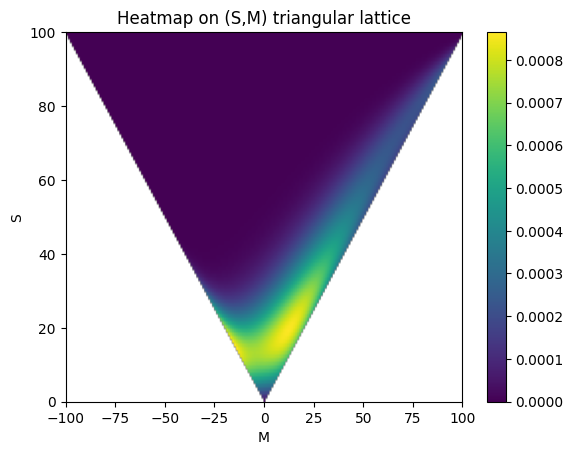

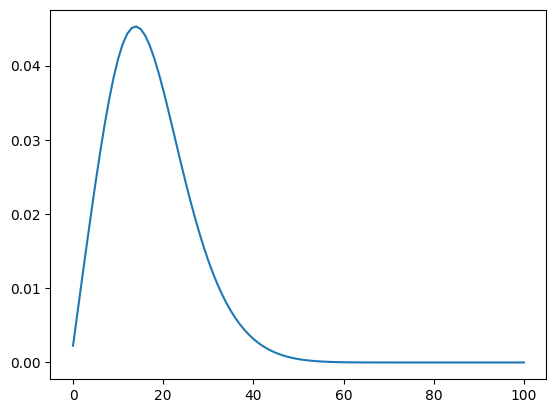

In [ ]:
using PyPlot

function plot_SM_heatmap(index_mapping, basis, amp)
    S_all = sort(unique(first.(basis)))
    M_all = sort(unique(last.(basis)))

    A = fill(NaN, length(S_all), length(M_all))

    for (S,M) in basis
        i = findfirst(==(S), S_all)
        j = findfirst(==(M), M_all)
        A[i, j] = amp[index_mapping[(S, M)]]
    end

    figure()
    imshow(A;
        origin="lower",
        cmap="viridis",
        aspect="auto",
        extent=[minimum(M_all), maximum(M_all), minimum(S_all), maximum(S_all)]
    )
    colorbar()
    xlabel("M")
    ylabel("S")
    title("Heatmap on (S,M) triangular lattice")

    figure()

    for col in eachcol(A)
        plot(col / sum(col))
    end
end

plot_SM_heatmap(index_mapping, basis, sol.u[500])
savefig("pops.pdf", bbox_inches = "tight")

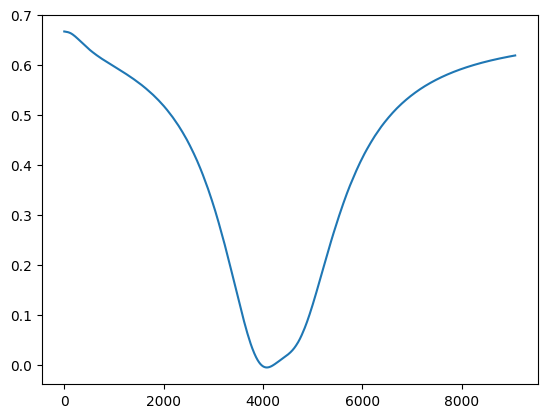

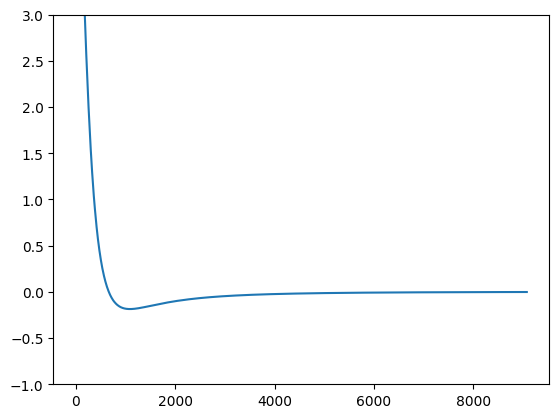

(-1.0, 3.0)

In [ ]:
function expect_smk(index_mapping, basis, amp, sk,mk)
    out = 0.0
    for (S, M) in basis
        out+= amp[index_mapping[(S, M)]] * S ^ sk * M ^ mk
    end
    return out
end

function calculate_measures(index_mapping, basis, amp)
    # 1. Calculate basic moments for S
    # We need <S>, <S^2>, <S^3>, <S^4>
    s1 = expect_smk(index_mapping, basis, amp, 0, 1)
    s2 = expect_smk(index_mapping, basis, amp, 0, 2)
    s3 = expect_smk(index_mapping, basis, amp, 0, 3)
    s4 = expect_smk(index_mapping, basis, amp, 0, 4)

    # 2. Central moments for Kurtosis
    # mu_k = <(s - <s>)^k>
    var_s = s2 - s1^2
    mu3 = s3 - 3*s1*s2 + 2*s1^3
    mu4 = s4 - 4*s1*s3 + 6*s1^2*s2 - 3*s1^4

    # --- THE MEASURES ---

    # Binder Cumulant (U4)
    # Gaussian = 0.666... 
    # Values significantly lower indicate non-Gaussianity/Bimodality
    u4 = 1.0 - (s4 / (3.0 * s2^2))

    # Excess Kurtosis (gamma2)
    # Gaussian = 0.0
    # Higher than 0 = "Spiky", Lower than 0 = "Flat/Bimodal"
    gamma2 = (mu4 / (var_s^2)) - 3.0

    # Relative Variance (Is the fluctuation O(1) or O(1/N)?)
    rel_var = var_s / s1^2

    return (binder=u4, kurtosis=gamma2, rel_var=rel_var)
end
res = [calculate_measures(index_mapping, basis, sol.u[i]) for i=1:length(sol)]
plot(map(x->x.binder,res))
figure()
plot(map(x->x.kurtosis,res))
ylim(top = 3.0, bottom = -1.0)

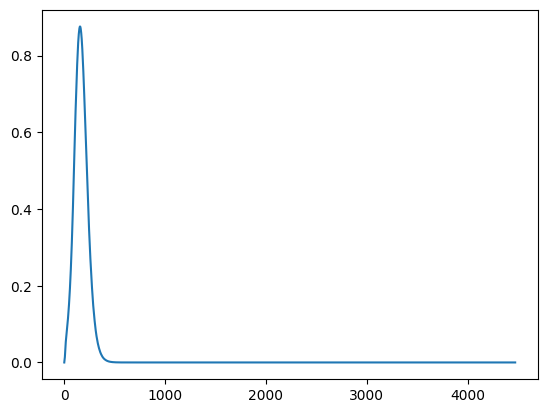

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x360b73cb0>

In [ ]:
Jmax = 100
N = 2 * Jmax
params = Dict("global_decay" => 1.0, "global_pump" => 0.0, "local_pump" => 0.0, "local_dephasing" => 10.0, "local_decay" => 0.0)

basis, index_mapping, Q, nstates = set_up_rate_matrix(Jmax, params)
p0 = initial_state(index_mapping, (Jmax, Jmax), nstates)

function f!(u, p, t)
    return Q * u
end

t = 5.0 / log(N)
prob = ODEProblem(f!, p0, (0.0, t), dt = 0.001)
sol = solve(prob, RK4())   # or Tsit5(), etc.

plot([expect_smk(index_mapping, basis, amp, 2,0) / N ^ 2 * 5-expect_smk(index_mapping, basis, amp, 0,2) / N^2 * 5 for amp in sol.u])

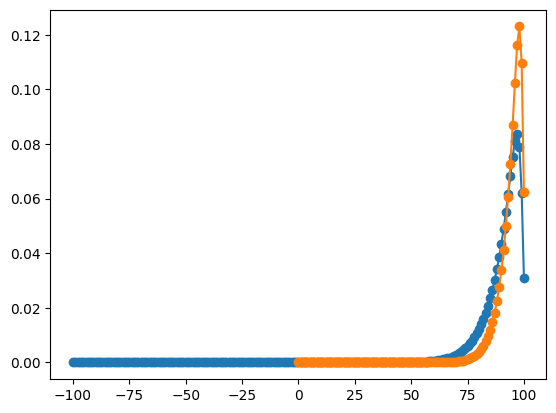

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x35718dbe0>

In [ ]:
function marginal_m(index_mapping, basis, amp)
    M_all = sort(unique(last.(basis)))
    Pm = zeros(Float64, length(M_all))
    for (S, M) in basis
        j = findfirst(==(M), M_all)
        Pm[j] += amp[index_mapping[(S, M)]]
    end
    Pm ./= sum(Pm)  # normalize
    return M_all, Pm
end

function marginal_s(index_mapping, basis, amp)
    S_all = sort(unique(first.(basis)))
    Ps = zeros(Float64, length(S_all))
    for (S, M) in basis
        i = findfirst(==(S), S_all)
        Ps[i] += amp[index_mapping[(S, M)]]
    end
    Ps ./= sum(Ps)
    return S_all, Ps
end

# plotting
Mvals, Pm = marginal_m(index_mapping, basis, sol.u[150])
plot(Mvals, Pm; marker=:o, label="P(m)")

Svals, Ps = marginal_s(index_mapping, basis, sol.u[150])
plot(Svals, Ps; marker=:o, label="P(s)")


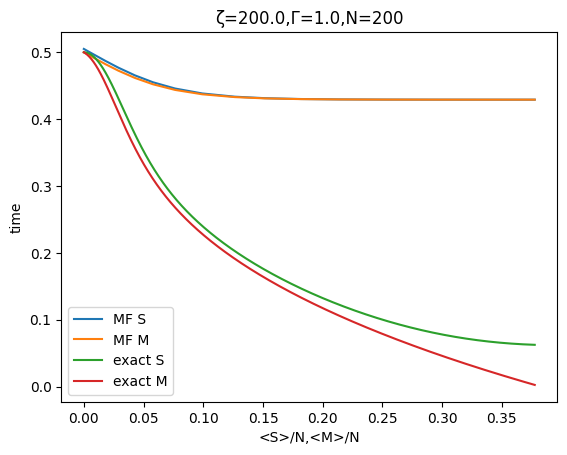

PyObject Text(0.5, 1.0, 'ζ=200.0,Γ=1.0,N=200')

In [ ]:
function meanfield_dephasing(u, p, t)
    du = copy(u)
    du[1] = -p[2] / 2 * (u[1]^2-u[2]^2) / u[1]
    du[2] = - p[3] * p[1] * (u[1] ^ 2- u[2] ^ 2)
    return du
end

p = [params["global_decay"], params["local_dephasing"], N]
u0 = [1/2 + 1/N, 1/2]

#t = 1.0 / log(N)
prob = ODEProblem(meanfield_dephasing, u0, (0.0, t), dt = 0.001, p; save_everystep=true)
mfsol = solve(prob, RK4())
plot(mfsol.t, map(x->x[1], mfsol.u), label = "MF S")
plot(mfsol.t, map(x->x[2], mfsol.u), label = "MF M")

Ms = expval_M.(sol.u, Ref(index_mapping))
Ss = expval_S.(sol.u, Ref(index_mapping))
plot(sol.t, Ss / N, label = "exact S")
plot(sol.t, Ms / N, label = "exact M")
legend()
savefig("comp.pdf")
xlabel("<S>/N,<M>/N")
ylabel("time")
title("ζ=$(params["local_dephasing"]),Γ=$(params["global_decay"]),N=$N")

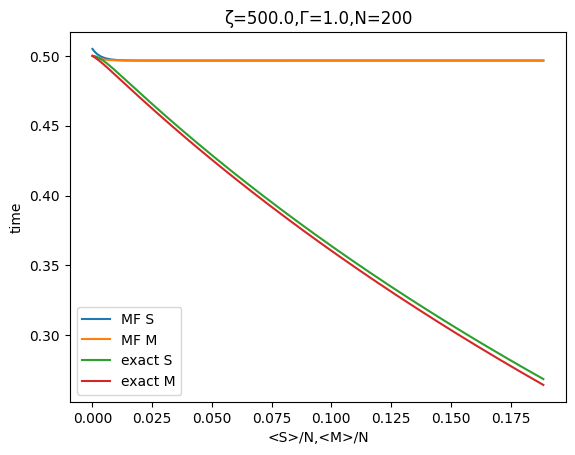

PyObject Text(0.5, 1.0, 'ζ=500.0,Γ=1.0,N=200')

In [ ]:
Jmax = 100
N = 2 * Jmax
params = Dict("global_decay" => 1.0, "global_pump" => 0.0, "local_pump" => 0.0, "local_dephasing" => 500.0, "local_decay" => 0.0)

basis, index_mapping, Q, nstates = set_up_rate_matrix(Jmax, params)
p0 = initial_state(index_mapping, (Jmax, Jmax), nstates)

function f!(u, p, t)
    return Q * u
end

t = 1.0 / log(N)
prob = ODEProblem(f!, p0, (0.0, t), dt = 0.001)
sol = solve(prob, RK4())   # or Tsit5(), etc.
sum(sol.u[end])

expval_S(state, index_mapping) = sum(state[value] * key[1] for (key,value) in index_mapping)
expval_M(state, index_mapping) = sum(state[value] * key[2] for (key,value) in index_mapping)

function meanfield_dephasing(u, p, t)
    du = copy(u)
    du[1] = -p[2] / 2 * (u[1]^2-u[2]^2) / u[1]
    du[2] = - p[3] * p[1] * (u[1] ^ 2- u[2] ^ 2)
    return du
end
t = 1.0 / log(N)

p = [params["global_decay"], params["local_dephasing"], N]
u0 = [1/2 + 1/N, 1/2]

prob = ODEProblem(meanfield_dephasing, u0, (0.0, t), dt = 0.001, p; save_everystep=true)
mfsol = solve(prob, RK4())
plot(mfsol.t, map(x->x[1], mfsol.u), label = "MF S")
plot(mfsol.t, map(x->x[2], mfsol.u), label = "MF M")

Ms = expval_M.(sol.u, Ref(index_mapping))
Ss = expval_S.(sol.u, Ref(index_mapping))
plot(sol.t, Ss / N, label = "exact S")
plot(sol.t, Ms / N, label = "exact M")
legend()
savefig("comp.pdf")
xlabel("<S>/N,<M>/N")
ylabel("time")
title("ζ=$(params["local_dephasing"]),Γ=$(params["global_decay"]),N=$N")

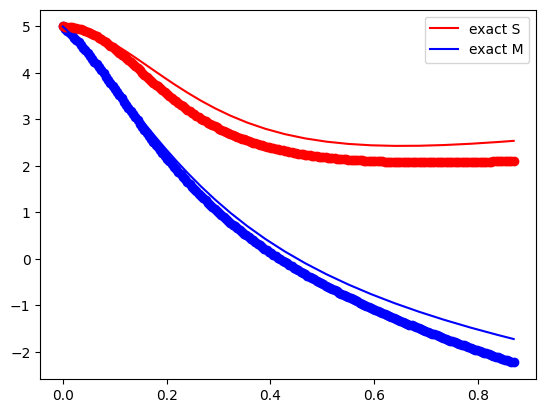

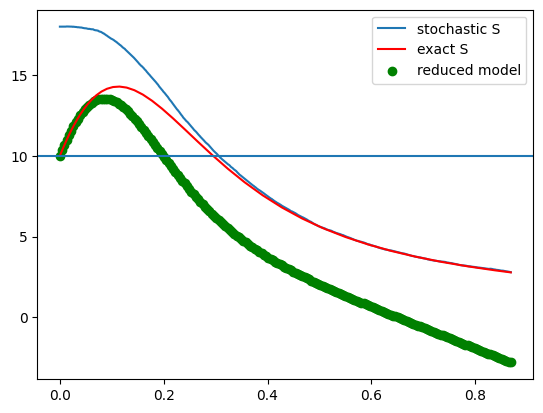

PyObject <matplotlib.lines.Line2D object at 0x17c3423c0>

: 

In [ ]:
"""
Coupled Markov chains for collective spin decay + dephasing
Implements the factorized marginal equations:
  - p_m(t): decay marginal (excitation dynamics)
  - p_s(t): dephasing marginal (spin dynamics)
coupled through ⟨s(s+1)⟩_d and ⟨m²⟩_j moments.
"""

using DifferentialEquations
using LinearAlgebra
using PyPlot

valid(s,m) = abs(m) <= s || isapprox(s, m, atol=1e-5)
svals(N) = range(-N/2, N/2)
mvals(N) = collect(0:N÷2)

function build_Lm(N, Γ, s_vals, ps)
    """Build the decay (m) Lindblad matrix given current p_s moments."""
    m_vals = svals(N)
    s_vals = mvals(N)
    @assert length(m_vals) == N+1
    

    L = zeros(N+1, N+1)
    for (i, m) in enumerate(m_vals)
        normalization = sum(p for (s,p) in zip(s_vals, ps) if valid(s,m); init = 0)
        ss1 = sum(s * (s + 1) * p for (s,p) in zip(s_vals, ps) if valid(s,m); init = 0) / normalization
        hm = Γ * (ss1 - m*(m-1))

        L[i, i] -= hm
        if i > 1
            L[i-1, i] += hm
        end
    end
    # To strictly keep (0,0) dark beyond numerical precision
    L[1,1] = 0.0
    return L, m_vals
end

function build_Ls(N, Γ, ξ, m_vals, pm)
    """Build the dephasing (s) matrix given current p_m moments."""
    m_vals = svals(N)
    s_vals = mvals(N)
    dim_s = length(s_vals)
    L = zeros(dim_s, dim_s)

    for (i, s) in enumerate(s_vals)
        m2 = 0.0
        m2 = sum(m ^ 2 * p for (m,p) in zip(m_vals, pm) if valid(s,m); init = 0) / sum(p for (m,p) in zip(m_vals, pm) if valid(s,m); init = 0)

        z_plus = s == N ÷ 2 ? 0.0 : ξ * (N - 2s) / (4*(s+1)*(2s+1)) * ((s+1)^2 - m2)
        z_minus = s == 0 ? 0.0 : ξ * (N + 2s + 2) / (4*s*(2s+1)) * (s^2 - m2)

        L[i, i] -= (z_plus + z_minus)

        # gain from s-1 (upward in s)
        if i < dim_s L[i+1, i] += z_plus end

        # gain from s+1 (downward in s)
        if i > 1 L[i-1, i] += z_minus end

    end
    return L, s_vals
end

function coupled_markov_ode!(du, u, p, t)
    N, Γ, ξ = p
    dim_m = N + 1
    dim_s = N ÷ 2 + 1

    pm = u[1:dim_m]
    ps = u[dim_m+1:end]
    # Renormalize to avoid drift
    pm ./= sum(pm)
    ps ./= sum(ps)

    s_vals = svals(N)
    m_vals = mvals(N)

    Lm, _ = build_Lm(N, Γ, s_vals, ps)
    Ls, _ = build_Ls(N, Γ, ξ, m_vals, pm)
    Ls[isnan.(Ls)] .= 0.0
    Lm[isnan.(Lm)] .= 0.0

    du[1:dim_m]        .= Lm * pm
    du[dim_m+1:end]    .= Ls * ps
end

# ─────────────────────────────────────────────
# Example run
# ─────────────────────────────────────────────
function run_simulation(; N=10, Γ=1.0, ξ=1.0, tspan=(0.0, 5.0))
    dim_m = N + 1
    dim_s = N ÷ 2 + 1

    # Initial condition: all atoms excited → m = N/2, s = N/2
    pm0 = zeros(dim_m); pm0[end] = 1.0       # m = N/2
    ps0 = zeros(dim_s); ps0[end] = 1.0       # s = N/2

    u0 = vcat(pm0, ps0)
    p  = (N, Γ, ξ)

    prob = ODEProblem(coupled_markov_ode!, u0, tspan, p)
    sol  = solve(prob, RK4(), saveat=range(tspan[1], tspan[2], length=200))
    return sol, N, Γ, ξ
end

# ─────────────────────────────────────────────
# Observables
# ─────────────────────────────────────────────
function extract_moments(sol, N)
    dim_m = N + 1
    m_vals = svals(N)
    s_vals = mvals(N)
    t = sol.t

    #p_sm(i) = 

    mean_m  = [sum(m_vals .* sol.u[i][1:dim_m]) / sum(sol.u[i][1:dim_m]) for i in 1:length(sol)]
    mean_s  = [sum(s_vals .* sol.u[i][dim_m+1:end])  / sum(sol.u[i][dim_m+1:end]) for i in 1:length(sol)]
    mean_m2  = [sum((m_vals .^ 2) .* sol.u[i][1:dim_m]) / sum(sol.u[i][1:dim_m]) for i in 1:length(sol)]
    mean_s2  = [sum((s_vals .^ 2) .* sol.u[i][dim_m+1:end])  / sum(sol.u[i][dim_m+1:end]) for i in 1:length(sol)]
    return t, mean_m, mean_s, mean_m2, mean_s2
end

# ─────────────────────────────────────────────
# Run and print
# ─────────────────────────────────────────────
N = 10
tmax = 2.0 / log(N)
params = Dict("global_decay" => 1.0, "global_pump" => 0.0, "local_pump" => 0.0, "local_dephasing" => 1.1 * N, "local_decay" => 0.0)

sol1, N, Γ, ξ = run_simulation(N=N, Γ=params["global_decay"], ξ= params["local_dephasing" ], tspan=(0.0, tmax))
t, mean_m, mean_s, mean_m2, mean_s2 = extract_moments(sol1, N)


## Test against true sim

Jmax = N ÷ 2
basis, index_mapping, Q, nstates = set_up_rate_matrix(Jmax, params)
p0 = initial_state(index_mapping, (Jmax, Jmax), nstates)

function f!(u, p, t)
    return Q * u
end

prob = ODEProblem(f!, p0, (0.0, tmax), dt = 0.001)
sol2 = solve(prob, RK4())   # or Tsit5(), etc.

expval_S(state, index_mapping) = sum(state[value] * key[1] for (key,value) in index_mapping)
expval_M(state, index_mapping) = sum(state[value] * key[2] for (key,value) in index_mapping)

expval_S2(state, index_mapping) = sum(state[value] * key[1] ^ 2 for (key,value) in index_mapping)
expval_M2(state, index_mapping) = sum(state[value] * key[2] ^ 2 for (key,value) in index_mapping)

Ms = expval_M.(sol2.u, Ref(index_mapping))
Ss = expval_S.(sol2.u, Ref(index_mapping))
Ms2 = expval_M2.(sol2.u, Ref(index_mapping))
Ss2 = expval_S2.(sol2.u, Ref(index_mapping))

scatter(sol1.t, mean_m, color = "blue")
scatter(sol1.t, mean_s, color = "red")
plot(sol2.t, Ss, label = "exact S", color = "red")
plot(sol2.t, Ms, label = "exact M", color = "blue")
legend()


figure()
t_axis, I_avg = simulate_ensemble(N, params["global_decay"], params["local_dephasing" ], 20000, tmax)
plot(t_axis, I_avg, label = "stochastic S")
plot(sol2.t, params["global_decay"] * (Ss2 .- Ms2 .+ Ss .+ Ms), label = "exact S", color = "red")
scatter(sol1.t, mean_s2 .- mean_m2 .+ mean_s .+ mean_m, color = "green", label = "reduced model")
legend()
axhline(N)